# Sequence Model (LSTM)

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import load_split, DATES, SYMBOLS
from src.baselines import tick_rule
from src.evaluate import metrics, full_report, print_report
from src.models.sequence import (
    SequenceConfig, SEQUENCE_FEATURES,
    train_sequence_model, load_artifacts, predict_proba,
)
from src.classify_side import classify_side

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
pd.set_option('display.float_format', '{:.4f}'.format)
print(f"torch {torch.__version__}  |  train {DATES['train']}  val {DATES['val']}")

torch 2.10.0+cpu  |  train 2026-04-12  val 2026-04-13


## 1. Loading the data

Pooling **both symbols** for training — the feature analysis showed WIFUSDT alone (~10.8k rows) is too small for a learned model to beat the tick rule, so it borrows strength from ZAMAUSDT (~31k rows). Windows are built *within* each symbol-day so no window ever spans a boundary.

In [2]:
train = load_split('train')   # {symbol: trades_df}
val   = load_split('val')
train_groups = list(train.values())
val_groups   = list(val.values())
for sym in SYMBOLS:
    print(f"{sym:10s} train {len(train[sym]):>7,}   val {len(val[sym]):>7,}")

WIFUSDT    train  10,805   val  14,868
ZAMAUSDT   train  31,162   val  32,408


## 2. Architecture

**Causal windowing.** For each trade *t*, the model sees the feature vectors of trades *[t-W+1 .. t]* (a backward
window of size `W`, left-padded with zeros for the first `W-1` trades). It predicts the side of the last trade in
the window. Because the window never looks forward, the model is valid for real-time use and cannot leak the future.

**Model.** `LSTM(num_layers=2, hidden=64)`. Trained with `BCEWithLogitsLoss` + Adam, early stopping on pooled validation loss.

In [3]:
config = SequenceConfig(window=32, hidden_size=64, num_layers=2,
                        dropout=0.2, epochs=25, patience=5, batch_size=512, seed=SEED)
print('window      :', config.window)
print('n_features  :', config.n_features)
print('hidden/layers:', config.hidden_size, '/', config.num_layers)
print('\nfeatures used:')
for f in SEQUENCE_FEATURES:
    print('  -', f)

window      : 32
n_features  : 16
hidden/layers: 64 / 2

features used:
  - tick_ff
  - tick_1
  - tick_2
  - tick_3
  - ret_1
  - ret_3
  - ret_10
  - dt_s
  - log_dt_s
  - vol_z_10
  - vol_z_50
  - log_amount
  - run_length
  - run_dir
  - pct_range_20
  - pct_range_50


## 3. Training

In [4]:
history = train_sequence_model(train_groups, val_groups, config, verbose=True)
print(f"\nbest pooled val_loss = {history['best_val_loss']:.4f}")

epoch  1  train_loss=0.5763  val_loss=0.4987  val_acc=0.7615


epoch  2  train_loss=0.5183  val_loss=0.4850  val_acc=0.7575


epoch  3  train_loss=0.4919  val_loss=0.4753  val_acc=0.7602


epoch  4  train_loss=0.4696  val_loss=0.4645  val_acc=0.7703


epoch  5  train_loss=0.4489  val_loss=0.4653  val_acc=0.7763


epoch  6  train_loss=0.4391  val_loss=0.4817  val_acc=0.7620


epoch  7  train_loss=0.4267  val_loss=0.4760  val_acc=0.7742


epoch  8  train_loss=0.4143  val_loss=0.4853  val_acc=0.7761


epoch  9  train_loss=0.4078  val_loss=0.4772  val_acc=0.7718
early stopping at epoch 9

best pooled val_loss = 0.4645


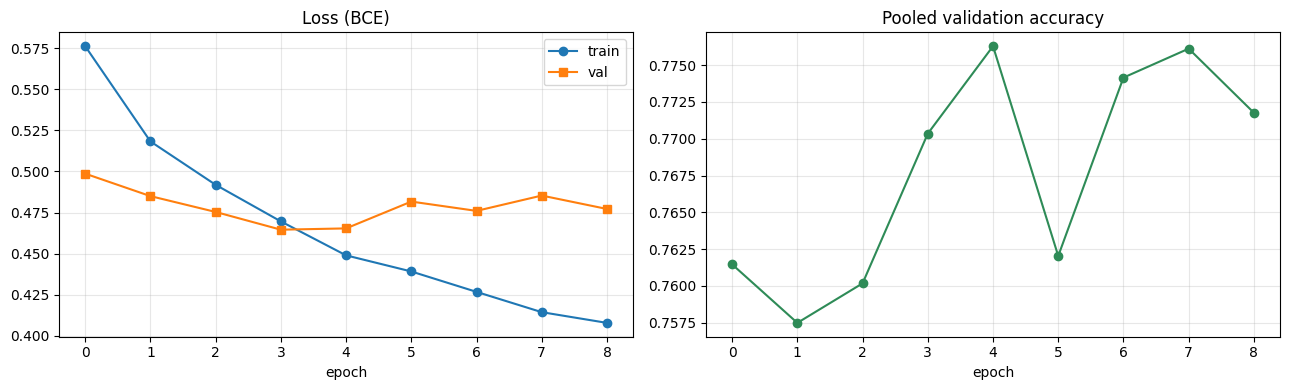

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['train_loss'], label='train', marker='o')
ax1.plot(history['val_loss'], label='val', marker='s')
ax1.set_title('Loss (BCE)'); ax1.set_xlabel('epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history['val_acc'], color='seagreen', marker='o')
ax2.set_title('Pooled validation accuracy'); ax2.set_xlabel('epoch'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Evaluation vs the tick-rule baseline


In [6]:
bundle = load_artifacts()
rows = []
for sym, df in val.items():
    y = df['side'].astype(bool)
    lstm_pred = predict_proba(bundle, df) >= 0.5
    m_lstm = metrics(y, lstm_pred)
    m_tick = metrics(y, tick_rule(df))
    rows.append({'symbol': sym, 'model': 'LSTM', **m_lstm})
    rows.append({'symbol': sym, 'model': 'tick rule', **m_tick})
res = pd.DataFrame(rows).set_index(['symbol', 'model'])[['accuracy', 'macro_f1', 'balanced_accuracy']]
print(res.to_string(float_format='{:.4f}'.format))

                    accuracy  macro_f1  balanced_accuracy
symbol   model                                           
WIFUSDT  LSTM         0.6835    0.6791             0.6819
         tick rule    0.7082    0.7082             0.7081
ZAMAUSDT LSTM         0.8102    0.8083             0.8074
         tick rule    0.7973    0.7971             0.7999


## 5. The public API — `classify_side`

In [ ]:
df = val['WIFUSDT']
out = classify_side(df)
print('type   :', type(out).__name__)
print('dtype  :', out.dtype)
print('len ok :', len(out) == len(df))
print('index ok:', out.index.equals(df.index))
print('no NaNs:', not out.isna().any())
print('\naccuracy vs ground truth:', f"{(out == df['side']).mean():.4f}")
out.head()

type   : Series
dtype  : bool
len ok : True
index ok: True
no NaNs: True

accuracy vs ground truth: 0.6835


2026-04-12 22:00:30.007233208+00:00    True
2026-04-12 22:00:30.007243289+00:00    True
2026-04-12 22:00:30.007245215+00:00    True
2026-04-12 22:00:30.007246791+00:00    True
2026-04-12 22:00:42.834605715+00:00    True
Name: predicted_side, dtype: bool

In [ ]:
tiny = df.iloc[:1]                       # single trade
empty = df.iloc[:0]                       # empty
no_side = df.drop(columns='side')         # no ground-truth column
print('single trade :', classify_side(tiny).tolist())
print('empty        :', len(classify_side(empty)), 'rows, dtype', classify_side(empty).dtype)
print('no side col  :', classify_side(no_side).equals(classify_side(df)))

single trade : [True]
empty        : 0 rows, dtype bool


no side col  : True
